In [ ]:
import kagglehub

path = kagglehub.dataset_download("naiyakhalid/flood-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flood-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/flood-prediction-dataset


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
train_path = os.path.join(path, "train.csv")

df = pd.read_csv(train_path)
df.head()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415


In [ ]:
df.columns

Index(['id', 'MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
       'InadequatePlanning', 'PoliticalFactors', 'FloodProbability'],
      dtype='object')

In [ ]:
X = df.drop(columns=["id", "FloodProbability"])
y = df["FloodProbability"]

In [ ]:
# from sklearn.ensemble import RandomForestRegressor

# # 1. Train a quick Random Forest model
# # (Using max_depth keeps it fast if your dataset is huge)
# model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
# model.fit(X, y)

# # 2. Extract feature importances
# importances = pd.Series(model.feature_importances_, index=X.columns)

# # 3. Sort and plot the results
# importances.sort_values(ascending=True).plot(kind='barh', figsize=(10, 6))
# plt.title("Feature Importance for Flood Probability")
# plt.xlabel("Importance Score")
# plt.show()

In [ ]:
# print(importances)

In [ ]:
import pandas as pd
import os

# 1. Load both datasets
train_df = pd.read_csv(os.path.join(path, "train.csv"))
test_df = pd.read_csv(os.path.join(path, "test.csv"))

# 2. Separate X and y
X_train = train_df.drop(columns=["id", "FloodProbability"])
y_train = train_df["FloodProbability"]

test_ids = test_df["id"] # Save ids for final submission
X_test = test_df.drop(columns=["id"])

# 3. Apply feature engineering to both
def add_features(df):
    original_cols = df.columns[:20] # Grab the original 20 features
    df['Global_Total'] = df[original_cols].sum(axis=1)
    df['Infrastructure_Health'] = df['DamsQuality'] + df['DrainageSystems'] + df['DeterioratingInfrastructure']
    df['Human_Impact'] = df['Deforestation'] + df['Urbanization'] + df['PopulationScore'] + df['Encroachments']
    df['Water_Metrics'] = df['MonsoonIntensity'] + df['RiverManagement'] + df['Siltation'] + df['TopographyDrainage']
    return df

X_train = add_features(X_train)
X_test = add_features(X_test)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
!pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.3 MB/s eta 0:00:00


In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# 1. Setup the ensemble
base_models = [
    ('xgb', XGBRegressor(random_state=42, n_jobs=-1)),
    ('lgbm', LGBMRegressor(random_state=42, n_jobs=-1)),
    ('cat', CatBoostRegressor(random_state=42, verbose=0))
]
meta_model = LinearRegression()
stacked_model = StackingRegressor(estimators=base_models, final_estimator=meta_model, cv=5)

# 2. Train on the full train data
print("Training on full dataset...")
stacked_model.fit(X_train_scaled, y_train)

# 3. Predict on test data
predictions = stacked_model.predict(X_test_scaled)

# 4. Save results to a CSV
submission = pd.DataFrame({
    'id': test_ids,
    'FloodProbability': predictions
})
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv successfully!")

Training on full dataset...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.389711 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 551
[LightGBM] [Info] Number of data points in the train set: 1117957, number of used features: 24
[LightGBM] [Info] Start training from score 0.504480
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.282751 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 550
[LightGBM] [Info] Number of data points in the train set: 894365, number of used features: 24
[LightGBM] [Info] Start training from score 0.504471


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.198691 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 550
[LightGBM] [Info] Number of data points in the train set: 894365, number of used features: 24
[LightGBM] [Info] Start training from score 0.504463


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.194915 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 552
[LightGBM] [Info] Number of data points in the train set: 894366, number of used features: 24
[LightGBM] [Info] Start training from score 0.504470


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.188168 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 550
[LightGBM] [Info] Number of data points in the train set: 894366, number of used features: 24
[LightGBM] [Info] Start training from score 0.504528


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.227132 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 550
[LightGBM] [Info] Number of data points in the train set: 894366, number of used features: 24
[LightGBM] [Info] Start training from score 0.504469


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Saved submission.csv successfully!


Training model for evaluation...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.373854 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 548
[LightGBM] [Info] Number of data points in the train set: 894365, number of used features: 24
[LightGBM] [Info] Start training from score 0.504480
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.152793 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 550
[LightGBM] [Info] Number of data points in the train set: 715492, number of used features: 24
[LightGBM] [Info] Start training from score 0.504504


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.147591 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 550
[LightGBM] [Info] Number of data points in the train set: 715492, number of used features: 24
[LightGBM] [Info] Start training from score 0.504482


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.171280 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 550
[LightGBM] [Info] Number of data points in the train set: 715492, number of used features: 24
[LightGBM] [Info] Start training from score 0.504468


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.155669 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 547
[LightGBM] [Info] Number of data points in the train set: 715492, number of used features: 24
[LightGBM] [Info] Start training from score 0.504457


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.153000 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 546
[LightGBM] [Info] Number of data points in the train set: 715492, number of used features: 24
[LightGBM] [Info] Start training from score 0.504490


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


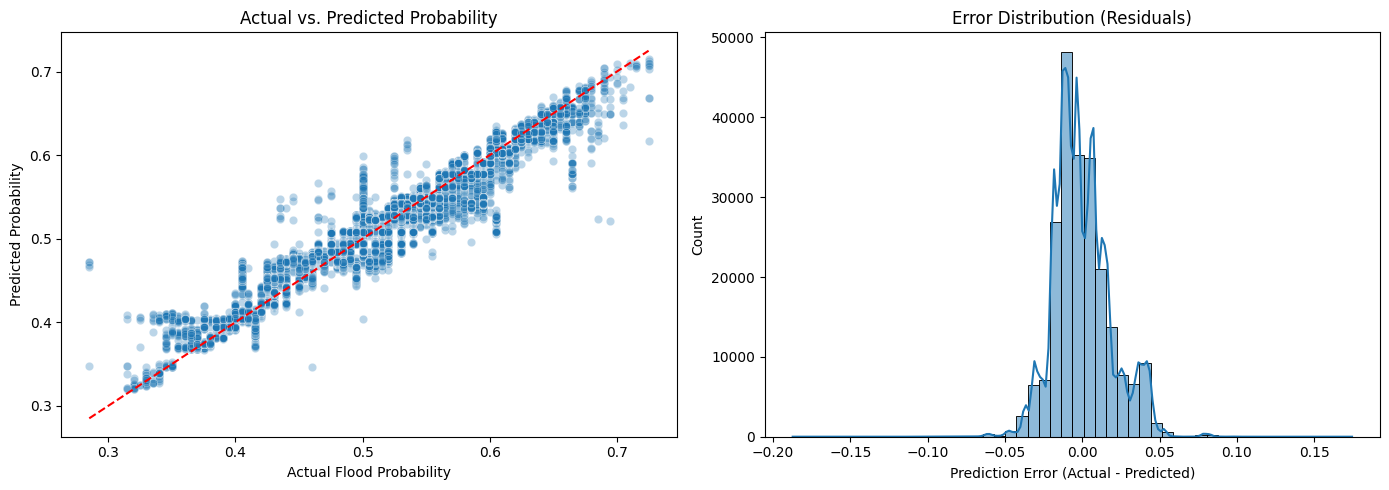

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Split a small validation set to check errors
X_t, X_val, y_t, y_val = train_test_split(X_train_scaled, y_train, test_size=0.2, random_state=42)

# 2. Train the model
print("Training model for evaluation...")
stacked_model.fit(X_t, y_t)

# 3. Get predictions for the validation set
y_pred = stacked_model.predict(X_val)
errors = y_val - y_pred

# 4. Draw the graphs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Actual vs Predicted
sns.scatterplot(x=y_val, y=y_pred, alpha=0.3, ax=axes[0])
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--') # Red line = perfect score
axes[0].set_title("Actual vs. Predicted Probability")
axes[0].set_xlabel("Actual Flood Probability")
axes[0].set_ylabel("Predicted Probability")

# Graph 2: Error Distribution
sns.histplot(errors, bins=50, kde=True, ax=axes[1])
axes[1].set_title("Error Distribution (Residuals)")
axes[1].set_xlabel("Prediction Error (Actual - Predicted)")

plt.tight_layout()
plt.show()